# Skenario 01 — Optimasi ABC untuk Random Forest dan SVR

Notebook ini meramalkan **`sisa jam` (RUL)** menggunakan seluruh data berstatus `Normal`, `Critical`, dan `Break`. Target dibentuk dari jam saat `Break` dikurangi `Unit Lifetime (Hour)`, lalu dibatasi maksimum 2.550 jam seperti proses data baru sebelumnya. Pembagian train-test dan K-Fold dilakukan secara acak dengan seed tetap.

Fitur model hanya terdiri atas delapan sensor. `Unit Lifetime (Hour)` hanya digunakan untuk membentuk target dan tidak diberikan kepada model. `Status` dipertahankan untuk analisis metrik per kelompok, tetapi juga tidak menjadi fitur model.

In [1]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix, f1_score, mean_absolute_error, mean_squared_error, precision_score, r2_score, recall_score
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

SEED = 42
np.random.seed(SEED)

## Konfigurasi dan persiapan data

In [2]:
SENSOR_COLS = [
    "Exhaust Gas Temperature LF (Left Front)",
    "Exhaust Gas Temperature LR (Left Rear)",
    "Exhaust Gas Temperature RF (Right Front)",
    "Exhaust Gas Temperature RR (Right Rear)",
    "Blowby Pressure (Kpa)",
    "Boost Pressure (Kpa)",
    "Engine Oil Temp (°C)",
    "Coolant Temp (°C)",
]
LIFE_COL = "Unit Lifetime (Hour)"
STATUS_COL = "Status"
TARGET_COL = "sisa jam"
FEATURE_COLS = SENSOR_COLS.copy()

cfg = {
    "data_file": "datas/Data_PT.Amanah_Critical_Break.xlsx",
    "max_rul": 2550.0,
    "test_size": 0.20,
    "cv_folds": 5,
    "population": 20,
    "iterations": 30,
    "limit": 8,
    "patience": 8,
    "thresholds": [100, 250, 500],
    "primary_threshold": 250,
}
RF_KEYS = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_features"]
RF_BOUNDS = np.array([[50, 300], [2, 30], [2, 20], [1, 10], [0.1, 1.0]], dtype=float)
SVR_KEYS = ["C", "epsilon", "gamma"]
SVR_BOUNDS = np.array([[0.1, 1000], [0.001, 50], [0.0001, 1]], dtype=float)

def find_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / cfg["data_file"]).exists():
            return path
    raise FileNotFoundError(f"Dataset tidak ditemukan: {cfg['data_file']}")

def prepare_data(root):
    raw = pd.read_excel(root / cfg["data_file"])
    data = raw[[*FEATURE_COLS, LIFE_COL, STATUS_COL]].copy()
    for col in FEATURE_COLS:
        data[col] = pd.to_numeric(data[col], errors="coerce")
    data[LIFE_COL] = pd.to_numeric(data[LIFE_COL], errors="coerce")
    data[STATUS_COL] = data[STATUS_COL].astype("string").str.strip().str.casefold()
    break_hour = data.loc[data[STATUS_COL].eq("break"), LIFE_COL].max()
    if pd.isna(break_hour):
        raise ValueError("Baris berstatus Break diperlukan untuk membentuk target sisa jam")
    data[TARGET_COL] = (break_hour - data[LIFE_COL]).clip(lower=0, upper=cfg["max_rul"])
    data = data.dropna(subset=[*FEATURE_COLS, STATUS_COL, TARGET_COL]).copy()
    if data.empty:
        raise ValueError("Data valid tidak ditemukan")
    return data, float(break_hour)

root = find_root()
out_dir = Path.cwd() / "artifacts" if Path.cwd().name == "01_RF_SVR_data_single" else root / "newcode/scenarios/01_RF_SVR_data_single/artifacts"
out_dir.mkdir(parents=True, exist_ok=True)
data, break_hour = prepare_data(root)
train_df, test_df = train_test_split(data, test_size=cfg["test_size"], shuffle=True, random_state=SEED)
X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]
cv = KFold(n_splits=cfg["cv_folds"], shuffle=True, random_state=SEED)
print({"baris_data": len(data), "distribusi_status": data[STATUS_COL].value_counts().to_dict(), "jam_break": break_hour, "fitur": FEATURE_COLS})

{'baris_data': 2568, 'distribusi_status': {'normal': 1847, 'critical': 720, 'break': 1}, 'jam_break': 78637.0, 'fitur': ['Exhaust Gas Temperature LF (Left Front)', 'Exhaust Gas Temperature LR (Left Rear)', 'Exhaust Gas Temperature RF (Right Front)', 'Exhaust Gas Temperature RR (Right Rear)', 'Blowby Pressure (Kpa)', 'Boost Pressure (Kpa)', 'Engine Oil Temp (°C)', 'Coolant Temp (°C)']}


## Model, fungsi objektif, dan Artificial Bee Colony

In [3]:
def decode_rf(pos):
    return {
        "n_estimators": int(round(pos[0])),
        "max_depth": int(round(pos[1])),
        "min_samples_split": int(round(pos[2])),
        "min_samples_leaf": int(round(pos[3])),
        "max_features": float(pos[4]),
    }

def decode_svr(pos):
    return {"C": float(pos[0]), "epsilon": float(pos[1]), "gamma": float(pos[2]), "kernel": "rbf"}

def make_model(kind, params):
    if kind == "rf":
        return RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
    return Pipeline([("scale", StandardScaler()), ("svr", SVR(**params))])

def make_objective(kind):
    decode = decode_rf if kind == "rf" else decode_svr
    cache = {}
    def objective(pos):
        params = decode(pos)
        key = tuple(round(val, 8) if isinstance(val, float) else val for val in params.values())
        if key not in cache:
            model = make_model(kind, params)
            scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="neg_mean_squared_error", n_jobs=1)
            cache[key] = float(-scores.mean())
        return cache[key]
    objective.cache = cache
    return objective

def run_abc(objective, bounds, population=20, iterations=30, limit=8, patience=8, seed=42, label="Model"):
    started = time.perf_counter()
    rng = np.random.default_rng(seed)
    low, high = bounds[:, 0], bounds[:, 1]
    food = rng.uniform(low, high, size=(population, len(bounds)))
    fit = np.array([objective(pos) for pos in food])
    trial = np.zeros(population, dtype=int)
    best_idx = int(np.argmin(fit))
    best_pos, best_fit = food[best_idx].copy(), float(fit[best_idx])
    history = [best_fit]
    stale = 0
    print(f"[{label}] Inisialisasi selesai | MSE CV terbaik: {best_fit:.6f}", flush=True)

    def explore(idx):
        other = rng.integers(0, population - 1)
        if other >= idx:
            other += 1
        dim = rng.integers(0, len(bounds))
        cand = food[idx].copy()
        cand[dim] += rng.uniform(-1, 1) * (food[idx, dim] - food[other, dim])
        cand = np.clip(cand, low, high)
        cand_fit = objective(cand)
        if cand_fit < fit[idx]:
            food[idx], fit[idx], trial[idx] = cand, cand_fit, 0
        else:
            trial[idx] += 1

    for iteration in range(1, iterations + 1):
        for idx in range(population):
            explore(idx)
        quality = 1.0 / (1.0 + fit - fit.min())
        prob = quality / quality.sum()
        for idx in rng.choice(population, size=population, p=prob):
            explore(int(idx))
        for idx in np.flatnonzero(trial >= limit):
            food[idx] = rng.uniform(low, high)
            fit[idx] = objective(food[idx])
            trial[idx] = 0
        idx = int(np.argmin(fit))
        if fit[idx] < best_fit:
            best_pos, best_fit = food[idx].copy(), float(fit[idx])
            stale = 0
        else:
            stale += 1
        history.append(best_fit)
        elapsed = time.perf_counter() - started
        print(f"[{label}] Iterasi {iteration}/{iterations} | MSE CV terbaik: {best_fit:.6f} | Waktu: {elapsed:.1f} detik", flush=True)
        if patience > 0 and stale >= patience:
            print(f"[{label}] Berhenti dini: {stale} iterasi tanpa perbaikan.", flush=True)
            break
    return best_pos, best_fit, history, len(objective.cache)

## Jalankan optimasi dan evaluasi

Cell berikut menjalankan optimasi penuh untuk dua model. Waktu proses bergantung pada perangkat.

In [4]:
def metric_values(actual, pred):
    mse = float(mean_squared_error(actual, pred))
    return {"mse": mse, "rmse": float(np.sqrt(mse)), "mae": float(mean_absolute_error(actual, pred)), "r2": float(r2_score(actual, pred))}

def make_threshold_rows(actual, pred, scope):
    rows = []
    for threshold in cfg["thresholds"]:
        actual_alert = np.asarray(actual) <= threshold
        predicted_alert = np.asarray(pred) <= threshold
        tn, fp, fn, tp = confusion_matrix(actual_alert, predicted_alert, labels=[False, True]).ravel()
        rows.append({
            "scope": scope, "threshold": int(threshold),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            "accuracy": float((tn + tp) / (tn + fp + fn + tp)),
            "precision": float(precision_score(actual_alert, predicted_alert, zero_division=0)),
            "recall": float(recall_score(actual_alert, predicted_alert, zero_division=0)),
            "f1": float(f1_score(actual_alert, predicted_alert, zero_division=0)),
        })
    return rows

def evaluate(kind, params, cv_mse, history, elapsed, evals):
    model = make_model(kind, params)
    oof_pred = cross_val_predict(model, X_train, y_train, cv=cv, n_jobs=1, method="predict")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    cv_metrics = metric_values(y_train, oof_pred)
    test_metrics = metric_values(y_test, pred)
    threshold_rows = [*make_threshold_rows(y_train, oof_pred, "cv_oof"), *make_threshold_rows(y_test, pred, "test")]
    cv_pred_df = train_df[[LIFE_COL, STATUS_COL, TARGET_COL]].copy().rename(columns={TARGET_COL: "actual_sisa_jam"})
    cv_pred_df["predicted_sisa_jam"] = oof_pred
    pred_df = test_df[[LIFE_COL, STATUS_COL, TARGET_COL]].copy().rename(columns={TARGET_COL: "actual_sisa_jam"})
    pred_df["predicted_sisa_jam"] = pred
    status_metrics = {}
    for status, group in pred_df.groupby(STATUS_COL):
        vals = metric_values(group["actual_sisa_jam"], group["predicted_sisa_jam"]) if len(group) >= 2 else {"mse": float(mean_squared_error(group["actual_sisa_jam"], group["predicted_sisa_jam"])), "rmse": float(np.sqrt(mean_squared_error(group["actual_sisa_jam"], group["predicted_sisa_jam"]))), "mae": float(mean_absolute_error(group["actual_sisa_jam"], group["predicted_sisa_jam"])), "r2": None}
        status_metrics[str(status)] = {"rows": int(len(group)), **vals}
    metrics = {
        "optimizer": "ABC", "model": "Random Forest" if kind == "rf" else "SVR",
        "data_scope": "all_status", "feature_scope": "sensor_only",
        "target": TARGET_COL, "features": FEATURE_COLS, "break_hour": break_hour,
        "best_params": params, "cv_mse": float(cv_mse), "cv_rmse": float(np.sqrt(cv_mse)),
        "test_mse": test_metrics["mse"], "test_rmse": test_metrics["rmse"], "test_mae": test_metrics["mae"], "test_r2": test_metrics["r2"],
        "cv_oof_metrics": cv_metrics, "test_metrics": test_metrics, "threshold_metrics": threshold_rows,
        "status_counts": {str(key): int(val) for key, val in data[STATUS_COL].value_counts().items()},
        "test_metrics_by_status": status_metrics, "elapsed_seconds": float(elapsed),
        "objective_evaluations": int(evals), "seed": SEED,
    }
    model_dir = out_dir / f"abc_{kind}"
    model_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, model_dir / "model.joblib")
    (model_dir / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    cv_pred_df.to_csv(model_dir / "cv_predictions.csv", index=False)
    pred_df.to_csv(model_dir / "test_predictions.csv", index=False)
    pd.DataFrame(threshold_rows).to_csv(model_dir / "threshold_metrics.csv", index=False)
    actual_color, pred_color = "tab:blue", "tab:orange"
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(history, color=actual_color, label="MSE CV terbaik")
    axes[0].set(title=f"Konvergensi ABC {metrics['model']}", xlabel="Iterasi", ylabel="MSE CV terbaik")
    axes[0].legend()
    axes[1].scatter(y_test, pred, color=pred_color, alpha=0.65, label="Prediksi")
    edge = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    axes[1].plot(edge, edge, color=actual_color, linewidth=2, label="Aktual ideal")
    axes[1].set(title=f"Aktual vs Prediksi {metrics['model']}", xlabel="Aktual sisa jam", ylabel="Prediksi sisa jam")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(model_dir / "evaluation.png", dpi=160, bbox_inches="tight")
    plt.show()
    primary = next(row for row in threshold_rows if row["scope"] == "cv_oof" and row["threshold"] == cfg["primary_threshold"])
    matrix = np.array([[primary["tn"], primary["fp"]], [primary["fn"], primary["tp"]]])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(y_train, oof_pred, color=pred_color, alpha=0.45, label="Prediksi OOF")
    edge = [min(y_train.min(), oof_pred.min()), max(y_train.max(), oof_pred.max())]
    axes[0].plot(edge, edge, color=actual_color, linewidth=2, label="Aktual ideal")
    axes[0].set(title=f"CV aktual vs prediksi {metrics['model']}", xlabel="Aktual sisa jam", ylabel="Prediksi OOF sisa jam")
    axes[0].legend()
    image = axes[1].imshow(matrix, cmap="Blues")
    for row in range(2):
        for col in range(2):
            axes[1].text(col, row, matrix[row, col], ha="center", va="center", color="black")
    axes[1].set(title=f"Confusion matrix CV ≤ {cfg['primary_threshold']} jam", xlabel="Prediksi", ylabel="Aktual", xticks=[0, 1], yticks=[0, 1], xticklabels=["Aman", "Peringatan"], yticklabels=["Aman", "Peringatan"])
    fig.colorbar(image, ax=axes[1], fraction=0.046)
    fig.tight_layout()
    fig.savefig(model_dir / "cv_validation.png", dpi=160, bbox_inches="tight")
    plt.show()
    return metrics

## Optimasi Random Forest

=== Mulai optimasi ABC Random Forest ===
[Random Forest] Inisialisasi selesai | MSE CV terbaik: 28177.258587
[Random Forest] Iterasi 1/30 | MSE CV terbaik: 25702.063300 | Waktu: 78.9 detik
[Random Forest] Iterasi 2/30 | MSE CV terbaik: 25702.063300 | Waktu: 136.8 detik
[Random Forest] Iterasi 3/30 | MSE CV terbaik: 25702.063300 | Waktu: 184.3 detik
[Random Forest] Iterasi 4/30 | MSE CV terbaik: 25702.063300 | Waktu: 231.3 detik
[Random Forest] Iterasi 5/30 | MSE CV terbaik: 24475.446337 | Waktu: 290.0 detik
[Random Forest] Iterasi 6/30 | MSE CV terbaik: 24380.970600 | Waktu: 337.7 detik
[Random Forest] Iterasi 7/30 | MSE CV terbaik: 24337.277899 | Waktu: 391.4 detik
[Random Forest] Iterasi 8/30 | MSE CV terbaik: 24087.552169 | Waktu: 471.6 detik
[Random Forest] Iterasi 9/30 | MSE CV terbaik: 24087.552169 | Waktu: 548.5 detik
[Random Forest] Iterasi 10/30 | MSE CV terbaik: 24087.552169 | Waktu: 615.7 detik
[Random Forest] Iterasi 11/30 | MSE CV terbaik: 24087.552169 | Waktu: 685.2 detik

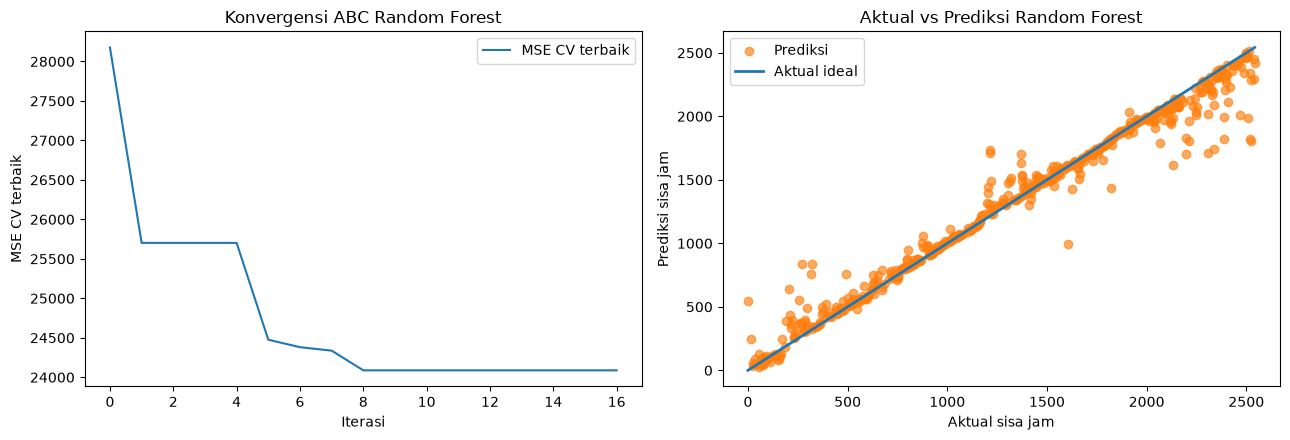

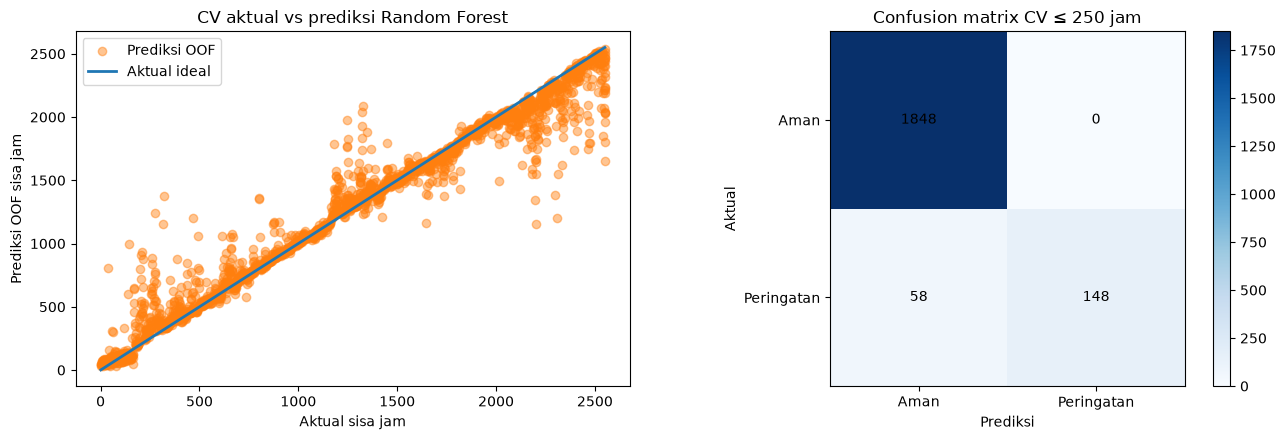

{'optimizer': 'ABC',
 'model': 'Random Forest',
 'data_scope': 'all_status',
 'feature_scope': 'sensor_only',
 'target': 'sisa jam',
 'features': ['Exhaust Gas Temperature LF (Left Front)',
  'Exhaust Gas Temperature LR (Left Rear)',
  'Exhaust Gas Temperature RF (Right Front)',
  'Exhaust Gas Temperature RR (Right Rear)',
  'Blowby Pressure (Kpa)',
  'Boost Pressure (Kpa)',
  'Engine Oil Temp (°C)',
  'Coolant Temp (°C)'],
 'break_hour': 78637.0,
 'best_params': {'n_estimators': 286,
  'max_depth': 20,
  'min_samples_split': 2,
  'min_samples_leaf': 1,
  'max_features': 0.8109062161431708},
 'cv_mse': 24087.552169384882,
 'cv_rmse': 155.20165002146362,
 'test_mse': 16681.476728315636,
 'test_rmse': 129.15679125897964,
 'test_mae': 64.69090991497009,
 'test_r2': 0.9683771225473483,
 'cv_oof_metrics': {'mse': 24087.45002686414,
  'rmse': 155.20132095721397,
  'mae': 79.13068753372728,
  'r2': 0.9565520476337199},
 'test_metrics': {'mse': 16681.476728315636,
  'rmse': 129.15679125897964,

In [5]:
print("=== Mulai optimasi ABC Random Forest ===", flush=True)
rf_start = time.perf_counter()
rf_obj = make_objective("rf")
rf_pos, rf_score, rf_history, rf_evals = run_abc(
    rf_obj, RF_BOUNDS, cfg["population"], cfg["iterations"],
    cfg["limit"], cfg["patience"], SEED, "Random Forest"
)
rf_result = evaluate(
    "rf", decode_rf(rf_pos), rf_score, rf_history,
    time.perf_counter() - rf_start, rf_evals
)
rf_result

## Optimasi SVR

=== Mulai optimasi ABC SVR ===
[SVR] Inisialisasi selesai | MSE CV terbaik: 14755.019011
[SVR] Iterasi 1/30 | MSE CV terbaik: 14755.019011 | Waktu: 63.6 detik
[SVR] Iterasi 2/30 | MSE CV terbaik: 13521.873013 | Waktu: 102.1 detik
[SVR] Iterasi 3/30 | MSE CV terbaik: 13361.374453 | Waktu: 154.2 detik
[SVR] Iterasi 4/30 | MSE CV terbaik: 13361.374453 | Waktu: 190.2 detik
[SVR] Iterasi 5/30 | MSE CV terbaik: 13361.374453 | Waktu: 240.3 detik
[SVR] Iterasi 6/30 | MSE CV terbaik: 13361.374453 | Waktu: 284.2 detik
[SVR] Iterasi 7/30 | MSE CV terbaik: 13361.374453 | Waktu: 328.9 detik
[SVR] Iterasi 8/30 | MSE CV terbaik: 13361.374453 | Waktu: 372.3 detik
[SVR] Iterasi 9/30 | MSE CV terbaik: 13361.374453 | Waktu: 419.9 detik
[SVR] Iterasi 10/30 | MSE CV terbaik: 13361.374453 | Waktu: 464.8 detik
[SVR] Iterasi 11/30 | MSE CV terbaik: 13361.374453 | Waktu: 515.4 detik
[SVR] Berhenti dini: 8 iterasi tanpa perbaikan.


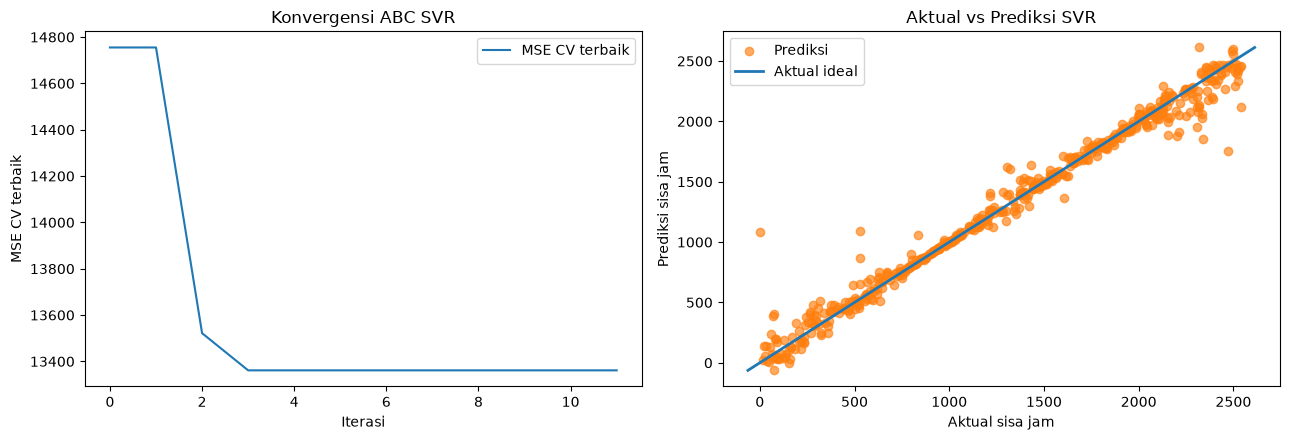

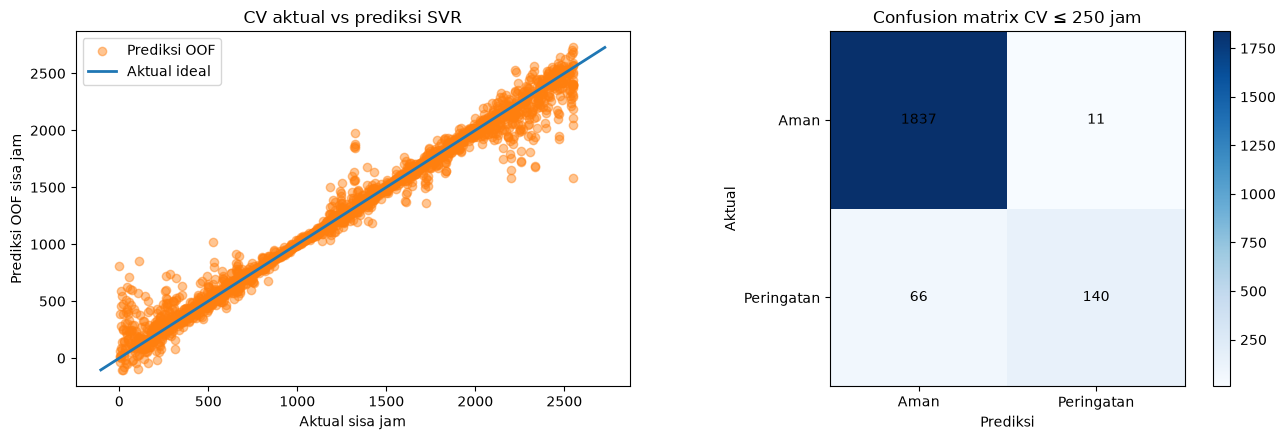

{'optimizer': 'ABC',
 'model': 'SVR',
 'data_scope': 'all_status',
 'feature_scope': 'sensor_only',
 'target': 'sisa jam',
 'features': ['Exhaust Gas Temperature LF (Left Front)',
  'Exhaust Gas Temperature LR (Left Rear)',
  'Exhaust Gas Temperature RF (Right Front)',
  'Exhaust Gas Temperature RR (Right Rear)',
  'Blowby Pressure (Kpa)',
  'Boost Pressure (Kpa)',
  'Engine Oil Temp (°C)',
  'Coolant Temp (°C)'],
 'break_hour': 78637.0,
 'best_params': {'C': 1000.0,
  'epsilon': 0.001,
  'gamma': 0.40072118910725946,
  'kernel': 'rbf'},
 'cv_mse': 13361.374452732101,
 'cv_rmse': 115.59141167375759,
 'test_mse': 11172.170040444538,
 'test_rmse': 105.69848646241127,
 'test_mae': 57.4198238262624,
 'test_r2': 0.9788210498492936,
 'cv_oof_metrics': {'mse': 13361.154428404123,
  'rmse': 115.59045993681366,
  'mae': 65.5812495277526,
  'r2': 0.975899698784372},
 'test_metrics': {'mse': 11172.170040444538,
  'rmse': 105.69848646241127,
  'mae': 57.4198238262624,
  'r2': 0.9788210498492936},


In [6]:
print("=== Mulai optimasi ABC SVR ===", flush=True)
svr_start = time.perf_counter()
svr_obj = make_objective("svr")
svr_pos, svr_score, svr_history, svr_evals = run_abc(
    svr_obj, SVR_BOUNDS, cfg["population"], cfg["iterations"],
    cfg["limit"], cfg["patience"], SEED + 1, "SVR"
)
svr_result = evaluate(
    "svr", decode_svr(svr_pos), svr_score, svr_history,
    time.perf_counter() - svr_start, svr_evals
)
svr_result

## Perbandingan hasil yang tersedia

In [7]:
results = {}
for kind in ["rf", "svr"]:
    path = out_dir / f"abc_{kind}" / "metrics.json"
    if path.exists():
        item = json.loads(path.read_text(encoding="utf-8"))
        if item.get("data_scope") == "all_status" and item.get("feature_scope") == "sensor_only":
            results[kind] = item
if not results:
    raise FileNotFoundError("Belum ada hasil ABC sensor-only untuk seluruh status. Jalankan minimal salah satu cell optimasi.")
pd.DataFrame(results).T[["cv_rmse", "test_rmse", "test_mae", "test_r2", "objective_evaluations"]]

,cv_rmse,test_rmse,test_mae,test_r2,objective_evaluations
rf,155.20165,129.156791,64.69091,0.968377,517
svr,115.591412,105.698486,57.419824,0.978821,398
